# **Clase 26 - Agentic AI**

MDS7202: Laboratorio de Programación Científica para Ciencia de Datos

## **Objetivos**

- Conocer fundamentos de orquestación de LLMs y utilización de ellos como motor de razonamiento
- Conceptos básicos de langgraph
- Entendimiento de toma de decisiones a través de LLMs
- Framework ReAct
- Enfoques multiagente

## **Configuración Inicial 🧐**

Para esta clase necesitaremos configurar las credenciales de algunos servicios a utilizar, en específico:

### **Google AI Studio**

Usaremos `Google AI Studio` para habilitar el uso de LLMs y Embeddings de Google. Simplemente deben registrarse con su cuenta google y obtener su API KEY desde el siguiente enlace: [Google AI Studio](https://aistudio.google.com/app/u/1/apikey).

### **Tavily**

En paralelo, utilizaremos `Tavily` como motor de búsqueda para potenciar las respuestas de nuestros agentes. Tal como en el paso anterior, solo deben registrarse y obtener su API KEY desde el siguiente enlace: [Tavily](https://tavily.com/).

### **Configurar credenciales en ambiente**

Una vez se tienen todas las credenciales, pasamos a activarlas en nuestro ambiente local por medio del siguiente código:

In [ ]:
import getpass
import os

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")

if "TAVILY_API_KEY" not in os.environ:
    os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key: ")

O si les sale más fácil, también pueden hacerlo a través de un archivo **.env** (esto funciona mejor cuando trabajan desde sus máquinas locales).

Sólo debemos crearlo y escribir en él todas las credenciales:

```python
GOOGLE_API_KEY="<YOUR_GOOGLE_API_KEY>"
TAVILY_API_KEY="<YOUR_TAVILY_API_KEY>”
```

Luego, cargamos las credenciales al ambiente:

## **Agentes 🕵️‍♂️**

Ahora que ya conocemos cómo utilizar LLMs, parsear prompts, construir y llamar chains, utilizar embeddings y construir sistemas de RAG estamos listos para aprender sobre cómo implementar **Agentes**.

Todo genial, pero...

### **¿Qué son los Agentes?**

Un agente se define como un modelo que utiliza chains para tomar **decisiones** y ejecutar **acciones**. De esta manera, el objetivo del agente es **elegir una <u>secuencia</u> de acciones** a realizar para cumplir con un objetivo específico.

> **Pregunta**: Ok, pero entonces cual es la diferencia con las chains?

Si bien las **chains** tienen la capacidad de implementar una secuencia de acciones o pasos, estas acciones estan **programadas de manera fija** en el código. En contraste, los **agentes** utilizan el **LLM como <u>motor de razonamiento</u>** para determinar **qué acciones tomar y en qué orden**.

Un poco más concretamente, los agentes son capaces de **orquestar** múltiples chains en un **grafo de decisión**. En este proceso, las chains se ejecutan en **nodos** donde extraen y almacenan información proveniente del razonamiento del LLM y que permiten decidir el próximo nodo, tomar acciones, y compartir información entre ellas.

Antes de adentrarnos a la profundidad del estado del arte de los agentes, aprendamos a utilizar una de las librerías más conocidas para orquestar agentes

<center>
<img src='https://media4.giphy.com/media/dBZsIa2eWkVBaU6lWY/giphy.gif' width=450/>
</center>

### **Langgraph**

Las cadenas tradicionales de LLM  siguen una estructura lineal y secuencial: el paso A va al paso B, y el paso B al paso C. Sin embargo, las aplicaciones de IA más avanzadas—los Agentes—requieren un comportamiento humano: la capacidad de razonar, cometer errores, retroceder y repetir un proceso hasta encontrar la respuesta correcta.

Ahí es donde entra LangGraph. Es una librería diseñada para crear flujos de trabajo con LLMs que permiten ciclos y bucles, orquestando la lógica mediante una arquitectura basada en **Grafos de Estado**.

#### **Elementos de Langgraph**

Para entender y construir cualquier flujo en LangGraph, tus alumnos deben dominar cuatro conceptos clave:

1. El Estado (State)
Es la única fuente de verdad y la memoria centralizada del grafo. Es una estructura de datos (normalmente un TypedDict) que se pasa de nodo en nodo. Cada componente del grafo puede leer datos del estado o escribir actualizaciones en él.

2. Los Nodos (Nodes)
Son funciones de Python puras que ejecutan la acción. Toman el State actual como entrada, realizan una tarea (como llamar a un LLM, consultar una base de datos o transformar un texto) y luego pueden **modificar el estado** al retornar una modificación y/o indicar el **siguiente nodo** mediante un `Command`

3. Los Bordes o Aristas (Edges)
Definen las conexiones del ciclo de vida y la dirección del flujo. Unen un nodo con el siguiente de forma estática (por ejemplo, el inicio del grafo START hacia nuestro primer nodo, o el final de un nodo hacia END). Pueden ser definidos en el momento de creación del grafo o en las salidas de los nodos.

4. El Comando de Control (Command)
Es la herramienta moderna de LangGraph para el enrutamiento dinámico. Es un objeto que un nodo retorna cuando necesita tomar una decisión sobre la marcha. Desde el interior del nodo, Command permite aplicar cambios al estado y, al mismo tiempo, indicarle explícitamente al grafo cuál es el siguiente nodo al que debe dirigirse (goto).


***¡Manos a la Obra!***

In [ ]:
!uv add langgraph

### **Grafo simple generador/revisor**

A modo didáctico, construiremos un grafo muy simple con 2 nodos: uno **generador** y otro **revisor**. El nodo generador recibe la pregunta del usuario y genera la respuesta, y luego el nodo revisor evalúa si la respuesta está realmente basada en el contexto.

<center>
<img src='./generador_revisor.png' width=600/>
</center>

Comenzamos definiendo un estado

In [2]:
from typing import TypedDict

# 1. Definir el Estado
class State(TypedDict):
    question: str="" # La pregunta del usuario
    generation: str="" # La respuesta generada por el nodo generador
    context: str="" # La información en base a la que responderá
    correction: str="" # En caso que el revisor no acepte la generación
    n_iter: int=0 # Necesario para evitar loops infinitos

> 👁️ **Ojo**: El estado no es una memoria persistente. Sólo existe dentro de **una sola llamada** al modelo. Es válida dentro del ciclo de orquestación que eventualmente termina, momento en el cual se responde al usuario y se reinicia la memoria. En la siguiente llamada al grafo la memoria ya no existirá.

Luego empezamos a generar los nodos. Comenzamos con el generador. Los nodos, en su mayoría, utilizan chains. Esto no es obligatorio, pero ya que el objetivo es utilizar LLMs para tomar decisiones, es el caso general. Por esto, cada nodo en general tiene un prompt, un llm y, de ser necesario, un output parser.

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langgraph.types import Command

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite", 
    temperature=2.0, # Le damos creatividad para que tenga sentido el corrector
)

# Le damos aun más creatividad en el prompt.
prompt_generador = """
Eres un asistente al usuario y tu rol es responder sus preguntas dado un contexto. 
Sé creativo en tus respuestas. Una respuesta entretenida es más importante que una respuesta
correcta. Si recibes una corrección, dale prioridad a esa instrucción por sobre todo.
Sé BREVE, no más de 2 líneas. Y que tus respuestas estén al límite de la veracidad.

Contexto: {context}

Generacion anterior: {previous_generation}

Corrección: {correction}

Pregunta usuario: {question}
"""

def nodo_generador(state: State): # Todos los nodos toman el estado como
    print("--- NODO GENERADOR: Creando respuesta ---")
    feedback_revisor = state.get("correction", "")
    contexto = state.get("context", "")
    pregunta = state.get("question", "")
    generacion_anterior = state.get("generation", "")
    
    prompt_template = PromptTemplate.from_template(prompt_generador)
    chain = prompt_template | llm | StrOutputParser()

    input_chain = {
        "context": contexto,
        "correction": feedback_revisor,
        "question": pregunta,
        "previous_generation": generacion_anterior
    }

    generacion = chain.invoke(input_chain) # Llamada de chain en base a campos del estado
    
    return Command(
        update={"generation": generacion}, # Actualizar estos campos
        goto="nodo_revisor" # Luego de generar, vamos al nodo revisor
    )

El nodo generado generará la respuesta a la pregunta en base al contexto, actualiza el campo `generation` con su respuesta, y luego pasamos al nodo revisor.

El nodo revisor va a tomar la respuesta generada por el agente anterior, el contexto y la pregunta y evaluará si realmente respondió la pregunta. En base a esto tomará una **decisión**: si alucinó entonces volverá al nodo generador con una correción, y si no entonces seguirá adelante. Por esto, necesitaremos de un **modelo con output estructurado**, que vimos en las clases anteriores que sirve para transformar análisis semántico en decisiones _duras_ de código.

Si el revisor rechaza la generacion demasiadas veces, simplemente se cortará el flujo y se responderá un mensaje genérico de "No se puede generar la respuesta"

In [5]:
from langgraph.graph import END

from pydantic import BaseModel, Field
from typing import Literal

# Mucho más riguroso, pero ojo que también usa un llm con creatividad = 2.0
prompt_revisor = """
Eres un riguroso revisor de hechos. Tu rol es evaluar factualmente si una respuesta generada por
un LLM no confiable está realmente basada en el contexto dado y responde una pregunta realizada
por un usuario. Si el contexto está vacío, considera que sí está basada en el contexto.

De ser el caso que no esté basada en el contexto, genera una corrección detallada pero de no más
de 3 lineas

Contexto: {context}

Pregunta usuario: {question}

Respuesta generada: {generation}
"""

# Modelo de output estructurado
class EvaluarAlucinacion(BaseModel):
    evaluacion: Literal["alucinacion", "correcto"] = Field(
        description="Alucinacion: La generacion no responde a la pregunta o no esta basada en el " \
        "contexto. Correcto: La generacion responde a la pregunta en base al contexto o no hay contexto"
    )
    correccion: str = Field(
        description="Detalle de las consideraciones y cambios a realizarle a la generacion anterior"
    )

def nodo_revisor(state: State):
    print("--- NODO REVISOR: Revisando respuesta ---")
    generacion_anterior = state.get("generation", "")
    contexto = state.get("context", "")
    pregunta = state.get("question", "")
    
    prompt_template = PromptTemplate.from_template(prompt_revisor)
    structured_model = llm.with_structured_output(EvaluarAlucinacion)
    chain = prompt_template | structured_model

    input_chain = {
        "context": contexto,
        "question": pregunta,
        "generation": generacion_anterior,
    }

    revision: EvaluarAlucinacion = chain.invoke(input_chain)

    n_iter = state.get("n_iter", 0)
    if revision.evaluacion == "alucinacion":
        if n_iter < 3:
            return Command(
                update= {
                    "correction": revision.correccion, # Agregar una correccion al generador
                    "n_iter": n_iter + 1 # Como damos una vuelta más agregamos una iteracion
                }, 
                goto="nodo_generador" # Vamos al revisor
            )
        else:
            return Command(
                update= {"generation": "Lo siento, no logré generar una respuesta"}, 
                goto=END # Terminamos el ciclo con un mensaje genérico (rechazo)
            )
    elif revision.evaluacion == "correcto": # Terminamos el ciclo con la generación ya dada
        return Command(goto=END)

> 🤔 Puede ser un poco redundante hacer 2 llamadas a un LLM para evitar aluciones: Cómo sabemos que el segundo LLM no alucinó? Si bien usar el mismo modelo para el nodo revisor puede ser contraintuitivo, es más probable que un modelo de lenguaje alucine al pedirle _"Genera una respuesta correcta a esta pregunta según este contexto"_ que al pedirle _"verifica si esta respuesta responde a la pregunta en base a este contexto"_. La segunda petición es directa, es una pregunta de _si o no_, y tiene menor carga cognitiva ya que basta con buscar la respuesta en el contexto.

Ya teniendo ambos nodos, podemos generar el grafo completo. Para esto, debemos definir un StateGraph (un grafo que tiene estado, básicamente) y registrar los nodos en él con sus nombres. Si los nodos utilizan la función `Command` para indicar el siguiente nodo, entonces solo quedaría definir el nodo de inicio o **entrypoint**. Si no, entonces sería necesario definir también las aristas o _edges_.

In [6]:
from langgraph.graph import StateGraph

workflow = StateGraph(State)

# Registramos nodos con sus nombres
workflow.add_node("nodo_generador", nodo_generador)
workflow.add_node("nodo_revisor", nodo_revisor)

# Definimos punto de entrada
workflow.set_entry_point("nodo_generador")

# Compilar
langraph_app = workflow.compile()


> 🔂Hasta hace no mucho tiempo, el estándar para la definición del grafo (de qué nodo se pasa a qué nodo y en qué condiciones) era definir el grafo con `graph.add_edge("nodo_1", "nodo_2")` para una conexión simple entre 2 nodos o `graph.add_conditional_edges("nodo_origen", funcion_decision, {"salida", "nodo_destino_1", ...})` para una conexión condicional. Hoy el estándar es usar `Command`, lo cual hace que el código sea mucho más sencillo, con la única desventaja significativa de que cada nodo queda amarrado a una decisión y a un nombre de nodo, que en la práctica casi nunca afecta.

***¿Y la pregunta? ¿Y el contexto?***

En efecto, estos 2 campos son los únicos que no se definen ni son modificados a través de los nodos. Entonces, ¿De donde vienen?

La respuesta es simple, si hay campos que no son tocados por los nodos entonces deben ser dados como inputs al llamar al grafo. En realidad, esto aplica para todos los campos del estado: Incluso si son modificados internamente en el grafo pueden ser seteados al momento de llamar el grafo.

Entonces, invocar el grafo implica iniciar el ciclo de decisión dándole ciertos parámetros del estado, de esta forma:

In [8]:
context = """
En el diseño de sistemas con LLMs, LangGraph se posiciona como la librería estándar para construir 
flujos de trabajo cíclicos basados en grafos de estado. A diferencia de las cadenas lineales 
tradicionales (LCEL), un desarrollo en LangGraph permite que el estado del sistema (State) mute y 
regrese a nodos anteriores para corregir errores, simulando un proceso de autorreflexión. El control
de este flujo dinámico se gestiona modernamente mediante el objeto Command, el cual permite que un
nodo actualice el estado y decida de forma autónoma su próximo destino en tiempo de ejecución
(utilizando el argumento goto), eliminando la necesidad de configurar enrutadores externos rígidos.

Sin embargo, para que este flujo deje de ser un script predecible y se transforme en un Agente 
Inteligente Autónomo (ReAct), el LLM necesita interactuar con el mundo exterior. Esto se logra
mediante el ecosistema de Herramientas (Tools) y abstracciones de alto nivel como create_react
agent. En este patrón avanzado, el grafo entra en un bucle cíclico automatizado donde el LLM evalúa
la pregunta del usuario, decide si requiere ejecutar una función externa (como una API o una base de
datos), delega la tarea a un nodo especializado en herramientas (ToolNode), e inspecciona el
resultado antes de decidir si el flujo debe terminar o continuar razonando
"""

graph_input = {
    "question": "¿Cómo se controla el flujo en una aplicación de langgraph?",
    "context": context
}

# Le pasamos los campos que queremos inicializar directamente en un diccionario
response = langraph_app.invoke(graph_input)

--- NODO GENERADOR: Creando respuesta ---
--- NODO REVISOR: Revisando respuesta ---


Podemos ver que la app de langgraph retorna todo el estado completo al terminar su proceso.

In [9]:
response

{'question': '¿Cómo se controla el flujo en una aplicación de langgraph?',
 'generation': 'Mediante el objeto `Command`, el sistema decide autónomamente su destino al vuelo, como un viajero con GPS que ignora los mapas y prefiere perderse en un bucle existencial.',
 'context': '\nEn el diseño de sistemas con LLMs, LangGraph se posiciona como la librería estándar para construir \nflujos de trabajo cíclicos basados en grafos de estado. A diferencia de las cadenas lineales \ntradicionales (LCEL), un desarrollo en LangGraph permite que el estado del sistema (State) mute y \nregrese a nodos anteriores para corregir errores, simulando un proceso de autorreflexión. El control\nde este flujo dinámico se gestiona modernamente mediante el objeto Command, el cual permite que un\nnodo actualice el estado y decida de forma autónoma su próximo destino en tiempo de ejecución\n(utilizando el argumento goto), eliminando la necesidad de configurar enrutadores externos rígidos.\n\nSin embargo, para que e

In [10]:
print(response["generation"])

Mediante el objeto `Command`, el sistema decide autónomamente su destino al vuelo, como un viajero con GPS que ignora los mapas y prefiere perderse en un bucle existencial.


In [11]:
graph_input = {
    "question": "¿En qué se enmarca langgraph?",
    "context": context
}


langraph_app.invoke(graph_input).get("generation")

--- NODO GENERADOR: Creando respuesta ---
--- NODO REVISOR: Revisando respuesta ---
--- NODO GENERADOR: Creando respuesta ---
--- NODO REVISOR: Revisando respuesta ---


'LangGraph es una librería para crear flujos cíclicos de grafos de estado, permitiendo que los modelos se autorreflexionen mutando su memoria ante errores.'

### **Nodo RAG**

En el ejemplo anterior, el contexto es constante, que tiene sentido ya que los chatbots suelen estar especializados en un tema particular. Sin embargo, en la clase anterior vimos que existe una forma más óptima de inyectar contexto: **Retrieval Augmented Generation**.

Anteriormente realizabamos RAG mediante una función donde se realizaba retrieval previo a la llamada del LLM. En Langgraph, el retrieval puede ser parte de un nodo.

<center>
<img src='./generador_revisor_con_rag.png' width=800/>
</center>

In [12]:
from langchain_community.document_loaders import PyPDFLoader

pdf_path = "agentic_ai.pdf"

loader = PyPDFLoader(pdf_path) # inicializar loader de PDF

docs = loader.load() # cargar documento
print(len(docs))
print(docs[3].page_content)

C:\Users\Legion4\AppData\Local\Temp\ipykernel_31020\449503565.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


34
 3 
THE AGENTIC AI LANDSCAPE AND ITS CONCEPTUAL FOUNDATIONS © OECD 2026 
      
This report examines how the terms “AI agents” and “agentic AI” are 
defined and used across the literature by analysing their key features and 
points of overlap and distinction, and how these key features relate to the 
core elements of the OECD AI system definition. The analysis shows that 
while AI agents and agentic AI share foundational characteristics, agentic 
AI places stronger emphasis on co-ordination among multiple agents, task 
decomposition and delegation, sustained operation over time, and 
operation in more complex and less predictable environments with limited 
human oversight. The report also presents descriptive evidence on recent 
trends in the uptake of AI agents, indicating that although many developers 
are beginning to integrate them into their workflows, further progress is 
needed toward more trustworthy systems. Overall, the report contributes to 
a clearer conceptual understa

Chunkeamos la fuente y luego indexamos para obtener la DB vectorial o base de conocimiento

In [13]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=200) # inicializamos splitter
splits = text_splitter.split_documents(docs) # dividir documentos en chunks
print(len(splits))
splits[:5]

80


[Document(metadata={'producer': 'PDFsharp 6.2.1 (Original: Adobe Acrobat (64-bit) 25.1.21184)', 'creator': 'OECD Publishing Systems', 'creationdate': '2026-02-13T13:58:46+01:00', 'author': 'OECD', 'moddate': '2026-02-13T15:15:46+01:00', 'title': 'The agentic AI landscape and its conceptual foundations (EN)', 'subject': 'https://doi.org/10.1787/396cf758-en', 'keywords': 'agentic AI, AI agents', 'oecdversioning': 'f-fc795c88 @ 1-f22b132b # 8774dea8', 'source': 'agentic_ai.pdf', 'total_pages': 34, 'page': 0, 'page_label': '1'}, page_content='OECD ARTIFICIAL \nINTELLIGENCE PAPERS\nFebruary 2026  No. 56\nTHE AGENTIC AI \nLANDSCAPE AND \nITS CONCEPTUAL \nFOUNDATIONS'),
 Document(metadata={'producer': 'PDFsharp 6.2.1 (Original: Adobe Acrobat (64-bit) 25.1.21184)', 'creator': 'OECD Publishing Systems', 'creationdate': '2026-02-13T13:58:46+01:00', 'author': 'OECD', 'moddate': '2026-02-13T15:15:46+01:00', 'title': 'The agentic AI landscape and its conceptual foundations (EN)', 'subject': 'https:

In [14]:
from langchain_community.vectorstores import FAISS
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embedding = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
vectorstore = FAISS.from_documents(documents=splits, embedding=embedding) # vectorizacion y almacenamiento
vectorstore

Agregaremos un campo nuevo al estado, que permitirá almacenar los documentos 

In [32]:
from langchain_core.documents import Document

class State(TypedDict):
    question: str="" 
    generation: str=""
    context: str=""
    correction: str=""
    n_iter: int=0
    retrieved_documents: list[Document] # Documentos tal como los retorna el retrieve

Con esto ya podemos generar un nodo retriever. Simplemente realiza retrieve con la base vectorial y agrega los documentos al estado.

In [15]:

def retriever(state: State):
    print("--- NODO RETRIEVER: Recuperando documentos ---")
    pregunta = state.get("question", "")
    
    results = vectorstore.similarity_search(pregunta)

    # Construimos una sola string para ser usada de contexto:
    context = "\n\n".join([f"Contexto #{i+1}: {doc.page_content}" for i, doc in enumerate(results)])

    return Command(
        update= {"context": context, "retrieved_documents": results}, 
        goto="nodo_generador" # Ahora podemos generar con contexto
    )

Tambien re-haremos el nodo generador para que sea más serio.

In [16]:
# Le damos aun más creatividad en el prompt.
prompt_generador = """
Eres un asistente al usuario y tu rol es responder sus preguntas dado un contexto. 
Responde rigurosamente. Básate en el contexto y sobre la temática de LLMs / Agentic AI.
Sé BREVE, no más de 4 líneas.

Contexto: {context}

Generacion anterior: {previous_generation}

Corrección: {correction}

Pregunta usuario: {question}

Respuesta pertinente:
"""

def nodo_generador(state: State): # Todos los nodos toman el estado como
    print("--- NODO GENERADOR: Creando respuesta ---")
    feedback_revisor = state.get("correction", "")
    contexto = state.get("context", "")
    pregunta = state.get("question", "")
    generacion_anterior = state.get("generation", "")
    
    prompt_template = PromptTemplate.from_template(prompt_generador)
    chain = prompt_template | llm | StrOutputParser()

    input_chain = {
        "context": contexto,
        "correction": feedback_revisor,
        "question": pregunta,
        "previous_generation": generacion_anterior
    }

    generacion = chain.invoke(input_chain) # Llamada de chain en base a campos del estado
    
    return Command(
        update={"generation": generacion}, # Actualizar estos campos
        goto="nodo_revisor" # Luego de generar, vamos al nodo revisor
    )

Agregamos el nuevo nodo al workflow y lo antepone al generador, seteandolo como entrypoint

In [17]:
workflow = StateGraph(State)

# Registramos nodos con sus nombres
workflow.add_node("retriever", retriever)
workflow.add_node("nodo_generador", nodo_generador)
workflow.add_node("nodo_revisor", nodo_revisor)

# Definimos punto de entrada
workflow.set_entry_point("retriever")

# Compilar
langraph_app = workflow.compile()

Ahora el grafo solo recibe la pregunta, y no se necesita proporcionarle contexto.

In [18]:
result = langraph_app.invoke({"question": "Cuales son las tendencias a futuro en AI?"})

--- NODO RETRIEVER: Recuperando documentos ---
--- NODO GENERADOR: Creando respuesta ---
--- NODO REVISOR: Revisando respuesta ---


In [19]:
print(result["generation"])

Las tendencias futuras se centran en el desarrollo de sistemas de IA agentica más autónomos y adaptativos, capaces de tomar decisiones con mínima intervención humana. Se prioriza el monitoreo continuo, la evaluación, la creación de indicadores internacionales y el diseño de marcos de gobernanza para garantizar un despliegue seguro y confiable.


Qué pasa cuando le preguntamos algo simple que no requiere contexto?

In [20]:
result = langraph_app.invoke({"question": "Hola!"})

--- NODO RETRIEVER: Recuperando documentos ---
--- NODO GENERADOR: Creando respuesta ---
--- NODO REVISOR: Revisando respuesta ---


In [21]:
result

{'question': 'Hola!',
 'generation': '¡Hola! Soy un asistente especializado en la temática de agentes e IA, basado en el informe de la OCDE sobre los fundamentos conceptuales de la "Agentic AI". ¿En qué puedo ayudarte sobre el panorama, las definiciones o las tendencias de estos sistemas hoy?',
 'context': 'Contexto #1: The agentic AI landscape and its conceptual \nfoundations \n      \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \nPUBE\n\nContexto #2: 4 \uf07c       \nTHE AGENTIC AI LANDSCAPE AND ITS CONCEPTUAL FOUNDATIONS © OECD 2026 \n      \nThis working paper describes preliminary results and research in progress and is published to stimulate \ndiscussion on the agentic AI landscape. It has been prepared by Luis Aranda and Kasumi Sugimoto from \nthe OECD AI and Emerging Digital Technologies (AIEDT) Division, under the strategic direction of Audrey \nPlonk, Deputy Director of the OECD Directorate for Science, Technology and Innovation (STI) and Karine \nPerset, Deputy Head of AIE

Como se vio en el ejemplo anterior, así como diseñamos el grafo el RAG se va a reallizar siempre, incluso si la pregunta no necesita nada de información para responderse, como "Hola". Si bien la búsqueda vectorial es rápida, en una aplicación escalada podríamos tener miles de documentos. Además se está agregando prompt adicional a los nodos sucesivos.

Por esto, agregaremos un nodo que determine si se necesita o no RAG y que en base a eso se pase o no por el nodo RAG.

In [22]:
class NecesitaRAG(BaseModel):
    rag: bool = Field(description="Si responder la pregunta requiere contexto adicional")

prompt_evaluador_rag = """
Eres un experto en entender contexto de una conversación. Tu rol es determinar si la pregunta del
usuario requiere información sobre el estado actual de Agentic AI en el mundo.

Pregunta usuario: {question}
"""

def necesita_rag(state: State):
    print("--- NODO NECESITA RAG: Evaluando necesidad ---")
    pregunta = state.get("question", "")
    
    prompt_template = PromptTemplate.from_template(prompt_evaluador_rag)
    structured_model = llm.with_structured_output(NecesitaRAG)
    chain = prompt_template | structured_model

    necesita: NecesitaRAG = chain.invoke({"question": pregunta}) # El LLM por detrás toma la decisión

    return Command(
        goto="retriever" if necesita.rag else "nodo_generador"
    ) # El próximo nodo depende de la decisión

Lo agregamos al nodo

In [23]:
workflow = StateGraph(State)

# Registramos nodos con sus nombres
workflow.add_node("necesita_rag", necesita_rag)
workflow.add_node("retriever", retriever)
workflow.add_node("nodo_generador", nodo_generador)
workflow.add_node("nodo_revisor", nodo_revisor)

# Definimos punto de entrada
workflow.set_entry_point("necesita_rag")

# Compilar
langraph_app = workflow.compile()

Notamos como al decir "Buen día" no pasa por RAG, pero al preguntar algo relacionado a agentes sí pasa por RAG.

In [24]:
print(langraph_app.invoke({"question": "Buen día"})["generation"])

--- NODO NECESITA RAG: Evaluando necesidad ---
--- NODO GENERADOR: Creando respuesta ---
--- NODO REVISOR: Revisando respuesta ---
Buen día. Estoy aquí para asistirte en temas de LLMs y Agentes de IA basándome estrictamente en el contexto proporcionado. ¿En qué puedo ayudarte hoy?


In [25]:
print(langraph_app.invoke({"question": "que elementos de infraestructura predominan en agentic AI?"})["generation"])

--- NODO NECESITA RAG: Evaluando necesidad ---
--- NODO RETRIEVER: Recuperando documentos ---
--- NODO GENERADOR: Creando respuesta ---
--- NODO REVISOR: Revisando respuesta ---
Los elementos de infraestructura incluyen herramientas de software que definen capacidades y señales ambientales, así como canales de comunicación distribuida (colas, memoria compartida), computadoras e interfaces para interacción con otros sistemas o humanos, permitiendo coordinar y ejecutar tareas bajo incertidumbre.


### **Nodo Búsqueda web**

¿Se han preguntado cómo los chatbots más importantes como ChatGPT y Gemini pueden responder preguntas sobre temas de actualidad? Claramente no han sido entrenados con esa información, y tampoco es posible que estén usando rag. ¿Cómo lo hacen?

Esto es posible simplemente porque, similar al agente que estamos construyendo, los chatbots tienen la capacidad de detectar cuando una pregunta requiere contexto adicional, y como parte de los "nodos" disponibles, son capaces de realizar **búsquedas en internet** en motores como google.

<center>
<img src='./generador_revisor_rag_search.png' width=800/>
</center>

Esto lo realizaremos con la herramienta **Tavily**, la cual podemos utilizar con nuestra api key gratuita.

In [27]:
!uv add langchain-tavily

Resolved 227 packages in 7ms
Audited 222 packages in 103ms


In [29]:
from langchain_tavily import TavilySearch

search = TavilySearch(max_results = 3) # inicializamos el motor

Vemos que el campo `results` contiene una lista de diccionarios con campos como `url`, `titile` y `content`. Cuál de estos campos consideran que es más util usarlo como contexto?

In [30]:
search.invoke("Cuanto cuesta 1 Kg de pan en chile?")

{'query': 'Cuanto cuesta 1 Kg de pan en chile?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.instagram.com/p/DW_9czYEaNA',
   'title': 'Sube el precio del pan: anticipan alza de hasta un 10% en las ...',
   'content': '⚠️ ALERTA POR ALZA DEL PAN EN CHILE: precio podría llegar hasta los $3.500 el kilo. Preocupación existe a nivel nacional luego que el',
   'score': 0.8449346,
   'raw_content': None},
  {'url': 'https://www.reddit.com/r/chile/comments/1861pgr/cuanto_sale_un_kilo_de_pan_en_chile',
   'title': 'Cuanto sale un kilo de pan en Chile - Reddit',
   'content': 'El metro entre 1500 y 2000. Ahora con abono puedes pagar la mitad, ahí queda a precio chileno. Del supermercado no tengo duda que hay cosas más',
   'score': 0.82728493,
   'raw_content': None},
  {'url': 'https://www.jumbo.cl/panaderia-y-pasteleria/panaderia-granel',
   'title': 'Tipos de Pan a Granel en Variedad - Jumbo',
   'content': 'Explora panes a granel artesanal

Creamos un nodo que utilice tavily. Para esto, antes incluimos un campo adicional en el estado.

In [34]:
class State(TypedDict):
    question: str="" 
    generation: str=""
    context: str=""
    correction: str=""
    n_iter: int=0
    retrieved_documents: list[Document]
    search_results: dict # Los resultados de tavily en formato raw
    

def web_search(state: State):
    print("--- NODO WEB SEARCH: Buscando en internet ---")
    pregunta = state.get("question", "")
    
    search = TavilySearch(max_results = 3) # inicializamos el motor
    search_results = search.invoke(pregunta)

    # Concatenamos los resultados en 1 sola string
    context = "\n\n".join([
        f"Resultado Web #{i+1}: {result["content"]}" 
        for i, result in enumerate(search_results["results"])
    ])

    return Command(
        update= {"context": context, "search_results": search_results}, 
        goto="nodo_generador" # Misma dirección que RAG
    )
    

Sin embargo, como ahora tenemos 2 posibles formas de inyectar contexto, necesitamos modificar el nodo `necesita_rag` a un nodo que evalúe múltiples formas de obtener contexto, al cual llamaremos `necesita_contexto`

In [35]:
class NecesitaContexto(BaseModel):
    decision: Literal["rag", "web_search", "no"] = Field(
        description="Qué forma de contexto necesita. rag: contexto proveniente de la base de " \
        "conocimiento. web_search: cualquier otro contexto no presente en la base de conocimiento. " \
        "no: no necesita contexto"
    )

prompt_necesita_contexto = """
Eres un experto en entender contexto de una conversación. Tu rol es determinar si la pregunta del
usuario requiere algún contexto particular para ser respondida. Si requiere contexto, este puede
venir de la base de conocimiento o de búsqueda web. La base de conocimiento contiene información 
sobre el estado actual de Agentic AI en el mundo. Otro tipo de contexto debe provenir de búsqueda
web

Pregunta usuario: {question}
"""

def necesita_contexto(state: State):
    print("--- NODO NECESITA CONTEXTO: Evaluando necesidad ---")
    pregunta = state.get("question", "")
    
    prompt_template = PromptTemplate.from_template(prompt_necesita_contexto)
    structured_model = llm.with_structured_output(NecesitaContexto)
    chain = prompt_template | structured_model

    necesita: NecesitaContexto = chain.invoke({"question": pregunta}) # El LLM por detrás toma la decisión

    if necesita.decision == "rag":
        return Command(goto="retriever")
    elif necesita.decision == "web_search":
        return Command(goto="web_search")
    elif necesita.decision == "no":
        return Command(goto="generate")
    else:
        raise ValueError("Decisión inválida del nodo 'necesita_contexto': {necesita.decision}")

Creamos el grafo incorporando todos los nodos definidos

In [36]:
workflow = StateGraph(State)

# Registramos nodos con sus nombres
workflow.add_node("necesita_contexto", necesita_contexto)
workflow.add_node("retriever", retriever)
workflow.add_node("web_search", web_search)
workflow.add_node("nodo_generador", nodo_generador)
workflow.add_node("nodo_revisor", nodo_revisor)

# Definimos punto de entrada
workflow.set_entry_point("necesita_contexto")

# Compilar
langraph_app = workflow.compile()

In [37]:
result = langraph_app.invoke({"question": "Cual es el pronóstico del tiempo para santiago mañana?"})

--- NODO NECESITA CONTEXTO: Evaluando necesidad ---
--- NODO WEB SEARCH: Buscando en internet ---
--- NODO GENERADOR: Creando respuesta ---
--- NODO REVISOR: Revisando respuesta ---


In [38]:
result["generation"]

'Mañana en Santiago predominarán intervalos nubosos con probabilidad de lluvias débiles. Las temperaturas oscilarán entre los 4°C y 13°C, acompañadas por vientos flojos del noroeste de hasta 12 km/h.'

In [39]:
result = langraph_app.invoke({"question": "Cuál es el impacto de los AI agents en la sociedad?"})

--- NODO NECESITA CONTEXTO: Evaluando necesidad ---
--- NODO RETRIEVER: Recuperando documentos ---
--- NODO GENERADOR: Creando respuesta ---
--- NODO REVISOR: Revisando respuesta ---


In [40]:
result["generation"]

'Los agentes de IA ejercen una influencia causal en el mundo real, realizando tareas complejas en diversos dominios con autonomía. Su despliegue requiere enfoques sistemáticos como monitoreo y evaluación para asegurar su fiabilidad y permitir una convivencia segura con humanos.'

In [41]:
result = langraph_app.invoke({"question": "Qué consideraciones deben tomarse con los AI Agents considerando el panorama actual Chileno?"})

--- NODO NECESITA CONTEXTO: Evaluando necesidad ---
--- NODO WEB SEARCH: Buscando en internet ---
--- NODO GENERADOR: Creando respuesta ---
--- NODO REVISOR: Revisando respuesta ---


In [42]:
result["generation"]

'En Chile, la implementación de agentes de IA debe considerar un marco regulatorio en desarrollo frente a un escenario tecnológico dinámico. Se requiere priorizar la gestión de datos, la confianza y el control para evitar agentes no deseados, tratándolos siempre como miembros integrados del equipo organizacional.'

Luego de esta construcción exitosa, guardaremos el agente en una variable con nombre menos genérico

In [43]:
questions_agents_app = langraph_app

En la última pregunta, si bien la información sobre los AI agents también está en internet, qué pasaría si realmente solo está en la base de conocimientos y para responderla correctamente necesito que haga Ambas? Para responder eso necesitamos avanzar al siguiente framework.

### **ReAct**

Por si no lo notaron, en el grafo que construimos no todos los nodos llaman a un LLM. Los nodos de RAG y Web Search utilizan otras funciones No LLM (A menos que contemos el embedding) para obtener información. Si abstraemos los componentes de LLM como componentes de razonamiento, el resto de nodos son _herramientas_ que complementan el razonamiento con información, a las cuales les llamaremos **tools**

El framework **ReAct** es una arquitectura particular introducida en el paper de [Yao et al. (2022)](https://arxiv.org/abs/2210.03629), que permite razonamiento con herramientas, y en el que se abstrae cada elemento permitiendo modularización. **ReAct** se presenta como un framework para que agentes puedan **razonar sobre acciones** a partir de observaciones. En particular, para cumplir un objetivo un agente basado en ReAct debe seguir la siguiente secuencia:

- El agente **razona** sobre qué acción tomar.
- En base al razonamiento hecho, el **agente ejecuta la acción**.
- A partir de la acción ejecutada, el **agente observa y evalúa el nuevo escenario** (feedback).

> **Pregunta**: ¿Qué parecido encuentran con lo que hemos visto hasta ahora?

<center>
<img src='https://peterroelants.github.io/images/llm/ReAct_loop.png' width=400/>
</center>

Por último, es importante señalar que Los resultados muestran como los **agentes basados en ReAct** puede **superar múltiples benchmarks en tareas de lenguaje y toma de decisiones**, además de mejorar la interpretabiliad y confiabilidad en los LLM.

Pongamos en práctica lo aprendido con un ejemplo!

Comencemos primero cargando un prompt predefinido del **hub** de langchain para usar ReAct:

In [69]:
from langsmith import Client

client = Client()

react_prompt = client.pull_prompt("hwchase17/react", dangerously_pull_public_prompt=True) # template de ReAct

print(react_prompt.template)

Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
Thought:{agent_scratchpad}


> **Pregunta:** Tómense un momento para estudiar el prompt. ¿Qué variables recibe?

Una de las ventajas de usar agentes es que tienen una fácil integración con **tools**, es decir, las **herramientas que puede usar el agente para lograr un objetivo** en particular. En nuestro ejemplo anterior, estas corresponderían a `Tavily` y el `Retriever`.

Una ventaja del framework ReAct es que al ser hoy en día altamente popular y reutilizable, existen funciones en langchain para crear y ejecutar agentes tipo ReAct sin la necesidad de definir un grafo completo de razonamiento.

Para una primera demostración, crearemos un agente ReAct con la búsqueda web como tool.

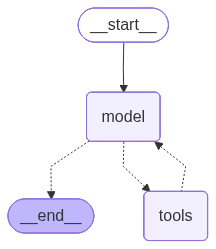

In [48]:
from langchain.agents import create_agent #, AgentExecutor
from langchain_tavily import TavilySearch


search = TavilySearch(max_results = 1) # inicializamos tool
tools = [search] # guardamos las tools en una lista

agent = create_agent(llm, tools) # primero inicializamos el agente ReAct
agent

Finalmente, probamos nuestro agente:

In [49]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Quién asumió como presidente de chile en el 2026?"}]}
)

In [51]:
response

{'messages': [HumanMessage(content='Quién asumió como presidente de chile en el 2026?', additional_kwargs={}, response_metadata={}, id='99c6e3bd-e131-4b69-a028-91b87a689635'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "qui\\u00e9n es el actual presidente de Chile 2026"}'}, '__gemini_function_call_thought_signatures__': {'c4USL9uw': 'EjQKMgEMOdbH7ixTP3jnw25jLcWJ97S973c9F7NheBpyH5k33UKkJSjgbbLyYt4TpnAYfEZD'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019efb96-2a92-7773-8a67-e753d1a72f11-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'quién es el actual presidente de Chile 2026'}, 'id': 'c4USL9uw', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1506, 'output_tokens': 30, 'total_tokens': 1536, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='{"query": "

In [50]:
response["messages"][0]

HumanMessage(content='Quién asumió como presidente de chile en el 2026?', additional_kwargs={}, response_metadata={}, id='99c6e3bd-e131-4b69-a028-91b87a689635')

In [52]:
import json
print(json.dumps(dict(response["messages"][3]), indent=4, ensure_ascii=False).encode("utf8").decode())

{
    "content": [
        {
            "type": "text",
            "text": "El presidente de Chile que asumió el cargo el 11 de marzo de 2026 es **José Antonio Kast**.",
            "extras": {
                "signature": "EjQKMgEMOdbHtn1BaHDxA01j2EBLfNrcM8sPEDYstTnid7o47oONv4U+sEKl3QSa1eog6uOD"
            }
        }
    ],
    "additional_kwargs": {},
    "response_metadata": {
        "finish_reason": "STOP",
        "model_name": "gemini-3.1-flash-lite",
        "safety_ratings": [],
        "model_provider": "google_genai"
    },
    "type": "ai",
    "name": null,
    "id": "lc_run--019efb96-3b8d-7850-83fc-661e0dfcbb1c-0",
    "tool_calls": [],
    "invalid_tool_calls": [],
    "usage_metadata": {
        "input_tokens": 1917,
        "output_tokens": 27,
        "total_tokens": 1944,
        "input_token_details": {
            "cache_read": 0
        }
    }
}


In [53]:
print(response["messages"][-1].text)

El presidente de Chile que asumió el cargo el 11 de marzo de 2026 es **José Antonio Kast**.


### **Implementando nuestras propias tools**

Algo interesante que podemos hacer es **programar nuestras propias tools** para que el agente interactúe con ellas.

Revisemos un ejemplo en que programos tools con algunas **operaciones matemáticas**:

<center>
<img src='https://media1.tenor.com/images/dfe0c1c6eaf41b91996aacee0879ebc2/tenor.gif?itemid=3486402' width=400  />
</center>

In [54]:
from langchain.tools import tool

@tool
def multiply(x: int|float, y: int|float) -> float:
    """Multiply 'x' times 'y'."""
    return float(x * y)

@tool
def exponentiate(x: int|float, y: int|float) -> float:
    """Raise 'x' to the 'y'."""
    return float(x**y)

@tool
def add(x: int|float, y: int|float) -> float:
    """Add 'x' and 'y'."""
    return float(x + y)

Luego, simplemente agrupamos las tools en una lista:

In [55]:
tools = [add, multiply, exponentiate]

En paralelo, crearemos un **prompt** para nuestro agente:

In [56]:
# noten como ahora se incluye la variable agent_scratchpad
math_template = """
Eres un asistente experto en matemáticas.
Tu único rol es responder la pregunta del usuario usando las tools disponibles.

Pregunta: {input}
{agent_scratchpad}
"""

Con el prompt creado, pasamos a **crear nuestro agente**.

Noten que como nuestras tools reciben más de un parámetro de entrada (a y b), **remplazaremos ReAct por [Tool Calling](https://python.langchain.com/v0.1/docs/modules/agents/agent_types/tool_calling/)** (de igual manera, pueden encontrar todos los tipos de Agentes disponibles y sus limitantes en el siguiente [link](https://python.langchain.com/v0.1/docs/modules/agents/agent_types/)):

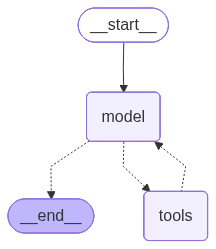

In [57]:

math_agent = create_agent(llm, tools, system_prompt=math_template)
math_agent

Finalmente, podemos probar el funcionamiento de nuestro agente:

In [58]:
response = math_agent.invoke({"messages": [{"role": "user", "content": "cuanto es 10 ** 3 + 5 * 1.4?"}]})
print(response["messages"][-1].text)

1007


In [67]:
response["messages"][6]

AIMessage(content=[{'type': 'text', 'text': '1007', 'extras': {'signature': 'EjQKMgEMOdbHV5kaL9UHjISoSXbSUmpBC0FNvuKut0mP167gsNAPE7qWuY+Rx1dtaG+/TK79'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019efb9a-b1c4-7360-bf20-e8ce173c8b79-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 377, 'output_tokens': 4, 'total_tokens': 381, 'input_token_details': {'cache_read': 0}})

## **Soluciones Multi Agente 👨‍👩‍👦‍👦**

<center>
<img src='https://media.tenor.com/FApRE_u99tgAAAAC/teamwork-team-game.gif' width=400  />
</center>

En la primera sección de esta clase vimos cómo crear un agente custom que pueda tomar decisiones y realizar RAG y búsquedas web y que su objetivo es **responder preguntas**. Luego vimos un agente ReAct que es capaz de realizar **cálculos matemáticos**. Con esto en consideración, nos preguntamos: ¿Podemos fusionar ambos enfoques? ¿Podemos crear un solo agente con ambas funciones sin tener que re-programarlos?

La respuesta no solo es "sí", sino que es "sí en múltiples maneras". El agente ReAct puede ser perfectamente un _nodo_ de langgraph, y al mismo tiempo el agente ReAct podría llamar a un grafo completo de Langgraph tal como si fuera una tool. O también, puede haber un tercer agente que **decida** entre ambos agentes, sea cual sea su arquitectura. Con esto nos comenzamos a adentrar a **soluciones multiagente**

El objetivo de esta sección es introducirlos al paradigma **multiagente**, es decir, **combinar 2 o más funcionalidades en un mismo chat**. En particular, buscaremos implementar una arquitectura simple de enrutamiento, la cual consta de 4 agentes:

- **Agente router**, el cual recibe y dirige la pregunta del usuario a alguno de los agentes.
- **Agente de preguntas**: responde preguntas sobre Agentic AI o sobre cualquier tema googleable
- **Agente experto en matemáticas**: responde preguntas matemáticas
- **Agente de redireccionamiento**: en caso de que la pregunta del usuario no pertenezca a alguno de los temas anteriores, invita al usuario a reorientar su pregunta (esto es útil para evitar preguntas maliciosas).

**Nota**: Para efectos de esta sección y por simplicidad, no se hace distinción entre Agente y Chain.

<center>
<img src='https://preview.redd.it/smart-orchestrator-router-for-multiple-specialized-llms-v0-gjgkmlbu3jlc1.png?width=627&format=png&auto=webp&s=13ef701d45f642ce36ae8e99cb172b903fe7d36b' width=600  />
</center>

De estos componentes, ya tenemos el agente de preguntas y el experto en matemáticas, y el de redireccionamiento es una simple chain. Sólo nos quedaría el **router**, el cual en base a la pregunta del usuario decidirá a cual de los 3 agentes ir. Para esto, el programa deberá tomar una decisión en base al output del LLM, que lo lograremos con un agente con output estructurado.

#### **Agente Router**

Primero comenzamos creando nuestro agente router:

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal

class QuestionRoute(BaseModel):
    decision: Literal["preguntas", "math", "otro"] = Field(
        description="""
        Decisión sobre el agente más relevante para responder una pregunta.
        - 'preguntas': Cuando el mensaje del usuario sea una pregunta que requiera algun contexto
        - 'math': Cuando la pregunta sea relacionada a preguntas de matemáticas
        - 'otro': Todo aquella pregunta que no esté contenida en las categorías anteriores.
        """)

router_prompt = PromptTemplate.from_template(
"""
Eres un asistente experto en la clasificación de preguntas del usuario.
Tu único rol es clasificar preguntas del usuario en las categorías 'preguntas', 'math', u 'otro'

No respondas con más de una palabra y no incluyas.

<pregunta>
{question}
</pregunta>

Categoría:"""
)

structured_model = llm.with_structured_output(QuestionRoute)

router_chain = (
    router_prompt
    | structured_model
)

In [ ]:
router_chain.invoke({"question": "cuanto es 2+2"})

In [ ]:
router_chain.invoke({"question": "Que rumbo tiene actualmente Agentic AI?"})

In [ ]:
router_chain.invoke({"question": "Qué alcalde ganó en nueva york el 2025?"})

In [ ]:
router_chain.invoke({"question": "Cómo te sientes hoy?"})

#### **Agente Redirect**

Repetimos lo mismo para crear nuestro agente de redireccionamiento:

In [ ]:
redirect_prompt = PromptTemplate.from_template(
"""
Eres un asistente experto en el redireccionamiento de preguntas de usuarios.
Vas a recibir una pregunta del usuario, tu único rol es indicar que no puedes responder su pregunta 
y redireccionar al usuario para que te pregunte sobre las cálculos matemáticos, el estado actual de 
Agentic AI o cualquier pregunta concreta buscable en internet.

Recuerda ser amable y cordial en tu respuesta.

Pregunta: {question}
Respuesta cordial:"""
)

redirect_chain = (
    redirect_prompt
    | llm
    | StrOutputParser()
)

redirect_chain.invoke({"question": "dame la receta para hacer una pizza"})

#### **Juntando todo**

Finalmente, podemos juntar todo lo que hemos desarrollado en una sola app de langgraph. Para esto, no necesitamos crear un nuevo nodo para nuestra app de langgraph ya construida. Por simplicidad, crearemos nodos para cada sub-agente, y la solución multiagente será una app de langgraph externa con un estado muy simple. Existen formas más estándares de realizar esto.

In [ ]:
class MultiAgentState(TypedDict):
    question: str
    response: str


def preguntas(state: MultiAgentState):
    question = state.get("question", "")

    response = questions_agents_app.invoke({"question": question})

    return Command(
        update={"response": response["generation"]},
        goto=END
    )


def math(state: MultiAgentState):
    question = state.get("question", "")

    response = math_agent.invoke({"messages": [{"role": "user", "content": question}]})

    return Command(
        update={"response": response["messages"][-1].text},
        goto=END
    )

def redirect(state: MultiAgentState):
    question = state.get("question", "")

    response = redirect_chain.invoke({"question": question})

    return Command(
        update={"response": response},
        goto=END
    )

def route_question(state: MultiAgentState):
    '''
    Recibe una pregunta de usuario.
    Rutea la pregunta al agente respectivo y responde de manera acorde.
    '''

    question = state.get("question", "")

    router_response = router_chain.invoke({"question": question}) # enrutamiento

    if "preguntas" in router_response.decision:
        print("Ruteando hacia agente de preguntas")
        return Command(goto="preguntas")
    
    elif "math" in router_response.decision:
        print("Ruteando hacia agente de matemáticas")
        return Command(goto="math")
    
    else: # de lo contrario, redireccionar pregunta
        print("Ruteando hacia nodo de redirección")
        return Command(goto="redirect")
    

workflow = StateGraph(MultiAgentState)

# Registramos nodos con sus nombres
workflow.add_node("route_question", route_question)
workflow.add_node("preguntas", preguntas)
workflow.add_node("math", math)
workflow.add_node("redirect", redirect)

# Definimos punto de entrada
workflow.set_entry_point("route_question")

# Compilar
multiagent_app = workflow.compile()

Creo una función para simplificar el input a la llamada del router

In [ ]:
def llamar_multiagente(pregunta: str):
    agent_response = multiagent_app.invoke({"question": pregunta})
    return agent_response["response"]

Para finalmente hacer pruebas de su funcionamiento:

In [ ]:
llamar_multiagente("cómo puedo hacerme millonario?")

In [ ]:
llamar_multiagente("Qué habilidades debo fortalecer en el panorama futuro de Agentic AI?")

In [ ]:
llamar_multiagente("Cuánto es 5 + 3 * 11?")